# Importing Basic Libraries

---



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# Generate Synthetic Clustering Dataset

In [ ]:
X, y_true = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

# This will generate the 500 sample data points with 3 centers and 0.60 standard
# deviation and the random state will be same

In [ ]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [ ]:
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


# Standard Scaling On Features & Converting Them In DataFrame

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
inertia = [] # This will store the value of WCSS later
K_range = range(1,10) # This is d1,d2,d3....till d10

# Performing K-Means Clustering

In [ ]:
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [ ]:
kmeans

KMeans(n_clusters=9, random_state=42)

In [ ]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074]

In [ ]:
best_inertia_value = min(inertia)

print(f"The best inertia value is {best_inertia_value}")

The best inertia value is 5.060234133532074


# Visualization

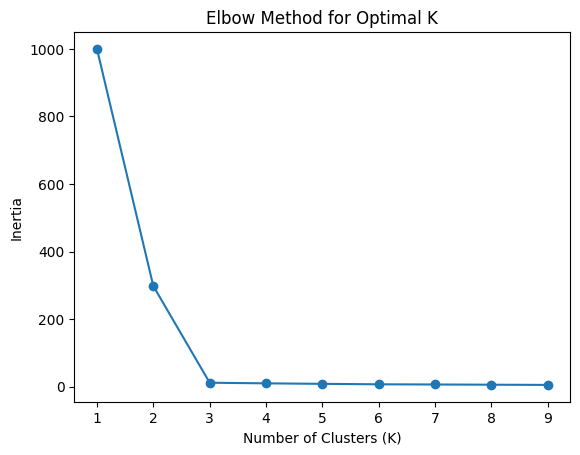

In [ ]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Finalizing K Means Clustering

In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit(X_scaled)

In [ ]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

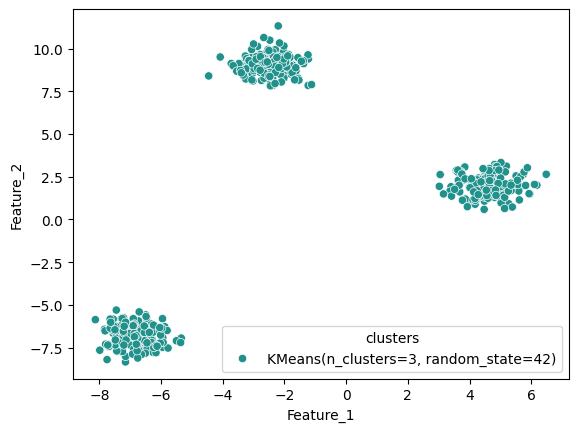

In [ ]:
sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['clusters'],
    palette='viridis'
)